In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = '../data'

In [3]:
df_model=pd.read_pickle(data_path + '/processed/df_model.pkl')

In [4]:
df_model.drop(
    columns=["Shipment_ID","Date"],
    inplace=True
)

In [5]:
corr_cols = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score",
    "Lead_Time_Days",
    "Disruption_Occurred"
]

df_model[corr_cols].corr()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
Distance_km,1.000000,-0.007016,-0.009501,0.028623,-0.011321,0.335665,0.009905
Weight_MT,-0.007016,1.000000,-0.022806,-0.000546,0.009955,-0.005838,0.012733
Fuel_Price_Index,-0.009501,-0.022806,1.000000,0.006807,-0.027467,-0.010256,0.003709
Geopolitical_Risk_Score,0.028623,-0.000546,0.006807,1.000000,0.010409,0.087650,0.225159
Carrier_Reliability_Score,-0.011321,0.009955,-0.027467,0.010409,1.000000,-0.008773,-0.078927
Lead_Time_Days,0.335665,-0.005838,-0.010256,0.087650,-0.008773,1.000000,0.265148
Disruption_Occurred,0.009905,0.012733,0.003709,0.225159,-0.078927,0.265148,1.000000


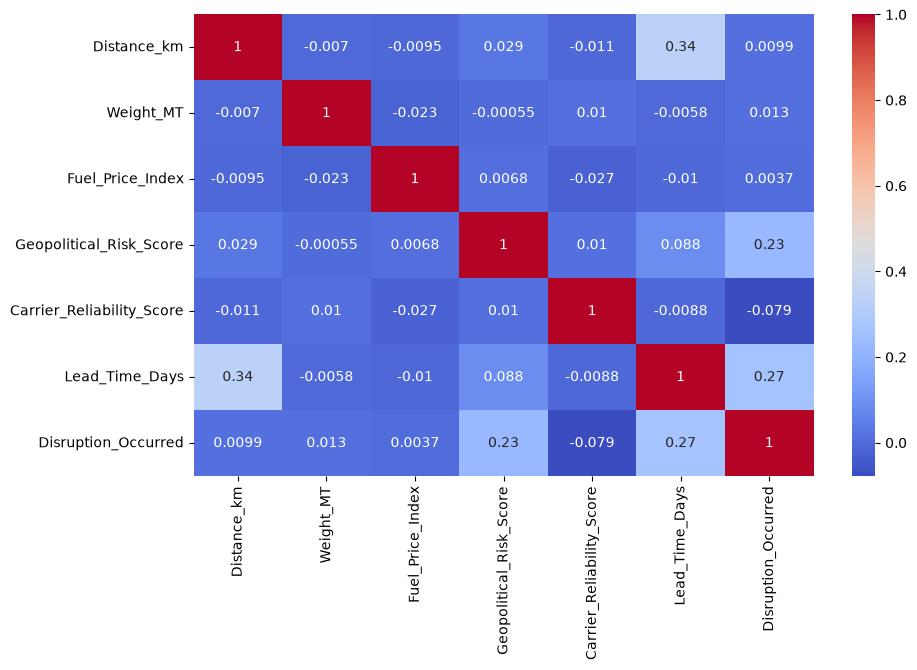

In [6]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_model[corr_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [7]:
df_model.head()

,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Quarter,Route,Reliability_Level,Risk_Level
0,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,2025,10,4,Singapore_to_Los Angeles,High,Medium
1,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,2024,4,2,Singapore_to_Shanghai,Low,High
2,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2024,1,1,Rotterdam_to_Los Angeles,Medium,Medium
3,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,2024,10,4,Busan_to_Hamburg,Medium,Low
4,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,2024,9,3,Busan_to_Singapore,Medium,Low


In [8]:
df_final = df_model.copy()
df_final.to_pickle(data_path + '/processed/df_final.pkl')

In [9]:
for col in [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition",
    "Route",
    "Risk_Level",
    "Reliability_Level"
]:
    print(col, ":", df_final[col].nunique())

Origin_Port : 8
Destination_Port : 9
Transport_Mode : 4
Product_Category : 5
Weather_Condition : 5
Route : 64
Risk_Level : 3
Reliability_Level : 3


In [12]:
cat_cols = [
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition",
    "Route",
    "Risk_Level",
    "Reliability_Level"
]

In [15]:
df_classification = df_final.drop(
    columns=[
        "Shipment_ID",
        "Date",
        "Origin_Port",
        "Destination_Port",
        "Lead_Time_Days"
    ],
    errors="ignore"
)

df_classification_encoded = pd.get_dummies(
    df_classification,
    columns=cat_cols,
    drop_first=True
)

df_classification_encoded.shape

(5000, 87)

In [16]:
df_regression = df_final.drop(
    columns=[
        "Shipment_ID",
        "Date",
        "Origin_Port",
        "Destination_Port",
        "Disruption_Occurred"
    ],
    errors="ignore"
)

df_regression_encoded = pd.get_dummies(
    df_regression,
    columns=cat_cols,
    drop_first=True
)

df_regression_encoded.shape

(5000, 87)

In [17]:
df_classification_encoded.to_pickle(data_path + '/processed/df_classification_encoded.pkl')
df_regression_encoded.to_pickle(data_path + '/processed/df_regression_encoded.pkl')